# Explorative Datenanalyse

## Struktur der Daten

In [420]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import os
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

In [421]:
# BindingDB_BindingDB_Articles.tsv mit UTF-8-Encoding laden. Es werden nur die Spalten 'Ligand SMILES', 'BindingDB Target Chain Sequence 1', 'IC50 (nM)', 'Ki (nM)' und 'Kd (nM)' geladen.
df = pd.read_csv("data/raw/BindingDB_BindingDB_Articles.tsv", sep='\t', encoding='utf-8')

C:\Users\hempe\AppData\Local\Temp\ipykernel_42268\3563842216.py:2: DtypeWarning: Columns (8,9,10,11,13,15,17,34,35,37,38,45,47,48,49,50,52,53,54,55,56,57,59,60,61,62,64,65,66,67,68,69,71,72,73,74,76,77,78,79,80,81,88,89,90,91,92,93,100,101,102,103,104,105,112,114,115,116,117,124,125,126,127,128,129,136,138,139,140,141,148,150,151,152,153,160,161,162,163,164,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/raw/BindingDB_BindingDB_Articles.tsv", sep='\t', encoding='utf-8')


In [422]:
#Get a quick overview of the columns in the dataframe
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93712 entries, 0 to 93711
Data columns (total 640 columns):
 #    Column                                                                Dtype  
---   ------                                                                -----  
 0    BindingDB Reactant_set_id                                             int64  
 1    Ligand SMILES                                                         object 
 2    Ligand InChI                                                          object 
 3    Ligand InChI Key                                                      object 
 4    BindingDB MonomerID                                                   int64  
 5    BindingDB Ligand Name                                                 object 
 6    Target Name                                                           object 
 7    Target Source Organism According to Curator or DataSource             object 
 8    Ki (nM)                                     

In [423]:
#Select features of interest
df=df[['Ligand SMILES', 'BindingDB Target Chain Sequence 1', 'IC50 (nM)', 'Ki (nM)', 'Kd (nM)']]
df.head()

,Ligand SMILES,BindingDB Target Chain Sequence 1,IC50 (nM),Ki (nM),Kd (nM)
0,COc1cc2c(Nc3ccc(Cl)cc3Cl)c(cnc2cc1OCCCN1CCN(C)CC1)C#N,MGSNKSKPKDASQRRRSLEPAENVHGAGGGAFPASQTPSKPASADGHRGPSAAFAPAAAEPKLFGGFNSSDTVTSPQRAGPLAGGVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL,8.7,NaN,NaN
1,COc1cc2c(Nc3cc(OC)c(OC)c(OC)c3)c(cnc2cc1OCCCN1CCN(C)CC1)C#N,MGSNKSKPKDASQRRRSLEPAENVHGAGGGAFPASQTPSKPASADGHRGPSAAFAPAAAEPKLFGGFNSSDTVTSPQRAGPLAGGVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL,5.1,NaN,NaN
2,COCCOc1cc2ncc(C#N)c(Nc3cc(OC)c(Cl)cc3Cl)c2cc1OCCOC,MGSNKSKPKDASQRRRSLEPAENVHGAGGGAFPASQTPSKPASADGHRGPSAAFAPAAAEPKLFGGFNSSDTVTSPQRAGPLAGGVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL,2.8,NaN,NaN
3,COCCOc1cc2ncc(C#N)c(Nc3ccc(Cl)cc3Cl)c2cc1OCCOC,MGSNKSKPKDASQRRRSLEPAENVHGAGGGAFPASQTPSKPASADGHRGPSAAFAPAAAEPKLFGGFNSSDTVTSPQRAGPLAGGVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL,12,NaN,NaN
4,COCCOc1cc2ncc(C#N)c(Nc3cc(OC)c(OC)c(OC)c3)c2cc1OCCOC,MGSNKSKPKDASQRRRSLEPAENVHGAGGGAFPASQTPSKPASADGHRGPSAAFAPAAAEPKLFGGFNSSDTVTSPQRAGPLAGGVTTFVALYDYESRTETDLSFKKGERLQIVNNTEGDWWLAHSLSTGQTGYIPSNYVAPSDSIQAEEWYFGKITRRESERLLLNAENPRGTFLVRESETTKGAYCLSVSDFDNAKGLNVKHYKIRKLDSGGFYITSRTQFNSLQQLVAYYSKHADGLCHRLTTVCPTSKPQTQGLAKDAWEIPRESLRLEVKLGQGCFGEVWMGTWNGTTRVAIKTLKPGTMSPEAFLQEAQVMKKLRHEKLVQLYAVVSEEPIYIVTEYMSKGSLLDFLKGETGKYLRLPQLVDMAAQIASGMAYVERMNYVHRDLRAANILVGENLVCKVADFGLARLIEDNEYTARQGAKFPIKWTAPEAALYGRFTIKSDVWSFGILLTELTTKGRVPYPGMVNREVLDQVERGYRMPCPPECPESLHDLMCQCWRKEPEERPTFEYLQAFLEDYFTSTEPQYQPGENL,25,NaN,NaN


<Axes: >

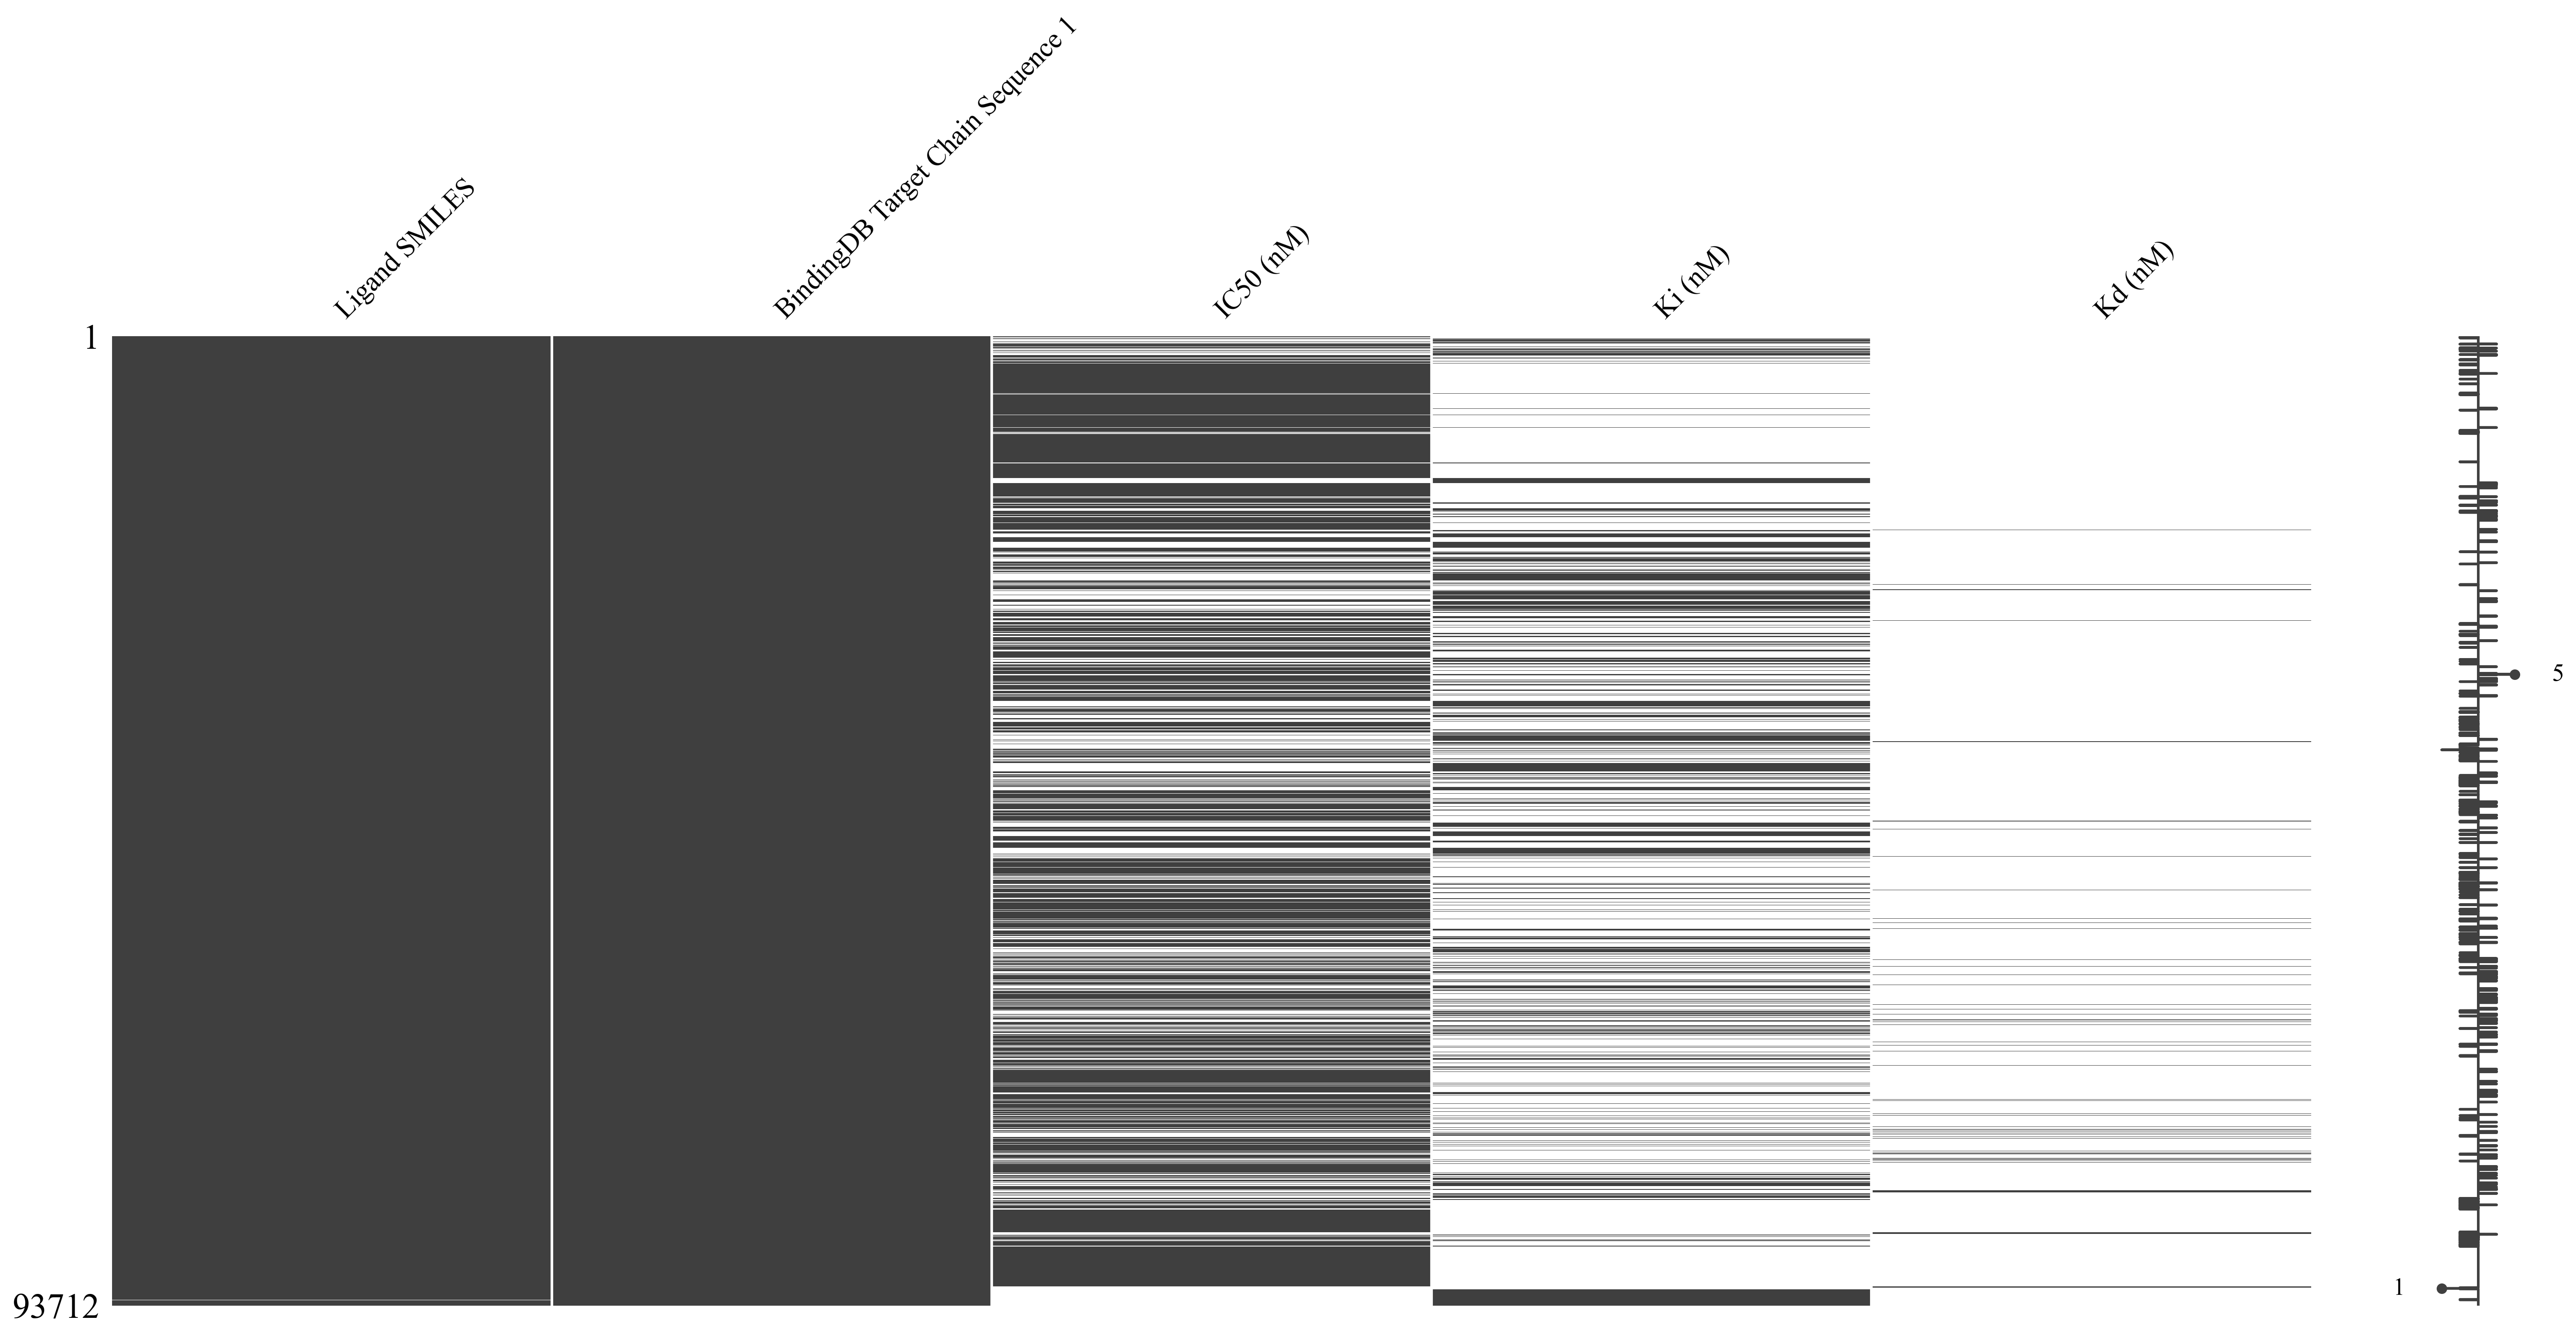

In [424]:
# Check for missing values
msno.matrix(df)

In [425]:
# Make sure column names are lower case and eliminate spaces
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
#Entferne Sonderzeichen aus den Spaltennamen
df.columns = df.columns.str.replace(r"[^a-z0-9_]", "", regex=True)
# rename column bindingdb_target_chain_sequence_1 into protein_sequence
df.rename(columns={'bindingdb_target_chain_sequence_1': 'protein_sequence'}, inplace=True)

In [426]:
# Show the number of null values for each column
null_kd = df["kd_nm"].isnull().sum()
null_ki = df["ki_nm"].isnull().sum()
null_ic50 = df["ic50_nm"].isnull().sum()

# Show the number of non-null values for each column
non_null_kd = df["kd_nm"].notnull().sum()
non_null_ki = df["ki_nm"].notnull().sum()
non_null_ic50 = df["ic50_nm"].notnull().sum()

# Show the number of numeric values for each column
numeric_kd = pd.to_numeric(df["kd_nm"], errors="coerce").notnull().sum()
numeric_ki = pd.to_numeric(df["ki_nm"], errors="coerce").notnull().sum()
numeric_ic50 = pd.to_numeric(df["ic50_nm"], errors="coerce").notnull().sum()

# Create a new dataframe with the counts
df_counts = pd.DataFrame({
    
    "Messgröße": ["Kd (nM)", "Ki (nM)", "IC50 (nM)"],
    "Number of missing values": [null_kd, null_ki, null_ic50],
    "Number of values": [non_null_kd, non_null_ki, non_null_ic50],
    "Number of numeric values": [numeric_kd, numeric_ki, numeric_ic50],
})

df_counts

,Messgröße,Number of missing values,Number of values,Number of numeric values
0,Kd (nM),91062,2650,2490
1,Ki (nM),67922,25790,22255
2,IC50 (nM),30187,63525,54885


In [427]:
#Eliminate all rows with non numeric values in the column ic50_nm. Non-numeric values will be converted to NaN and then removed.
df["ic50_nm"] = pd.to_numeric(df["ic50_nm"], errors="coerce")
df = df.dropna(subset=['ic50_nm'])


In [428]:
# Check for duplicates based on the columns ligand_smiles, protein_sequence and ic50_nm
anzahl_duplikate = df.duplicated(
    subset=["ligand_smiles", "protein_sequence", "ic50_nm"]
).sum()

anzahl_duplikate

2693

In [429]:
# Remove duplicates based on the columns ligand_smiles, protein_sequence and ic50_nm
df = df.drop_duplicates(
    subset=["ligand_smiles", "protein_sequence", "ic50_nm"],
    keep="first"
)
print("Neue Datensatzgröße:", df.shape)

Neue Datensatzgröße: (52192, 5)


## Verteilung der IC50 Werte

In [430]:
# Give a quick overview of the distribution of the IC50 (nM) values
df["ic50_nm"].describe()

count        52,192.00
mean        100,137.21
std       3,959,370.67
min               0.00
25%              58.00
50%             742.50
75%           8,400.00
max     459,000,000.00
Name: ic50_nm, dtype: float64

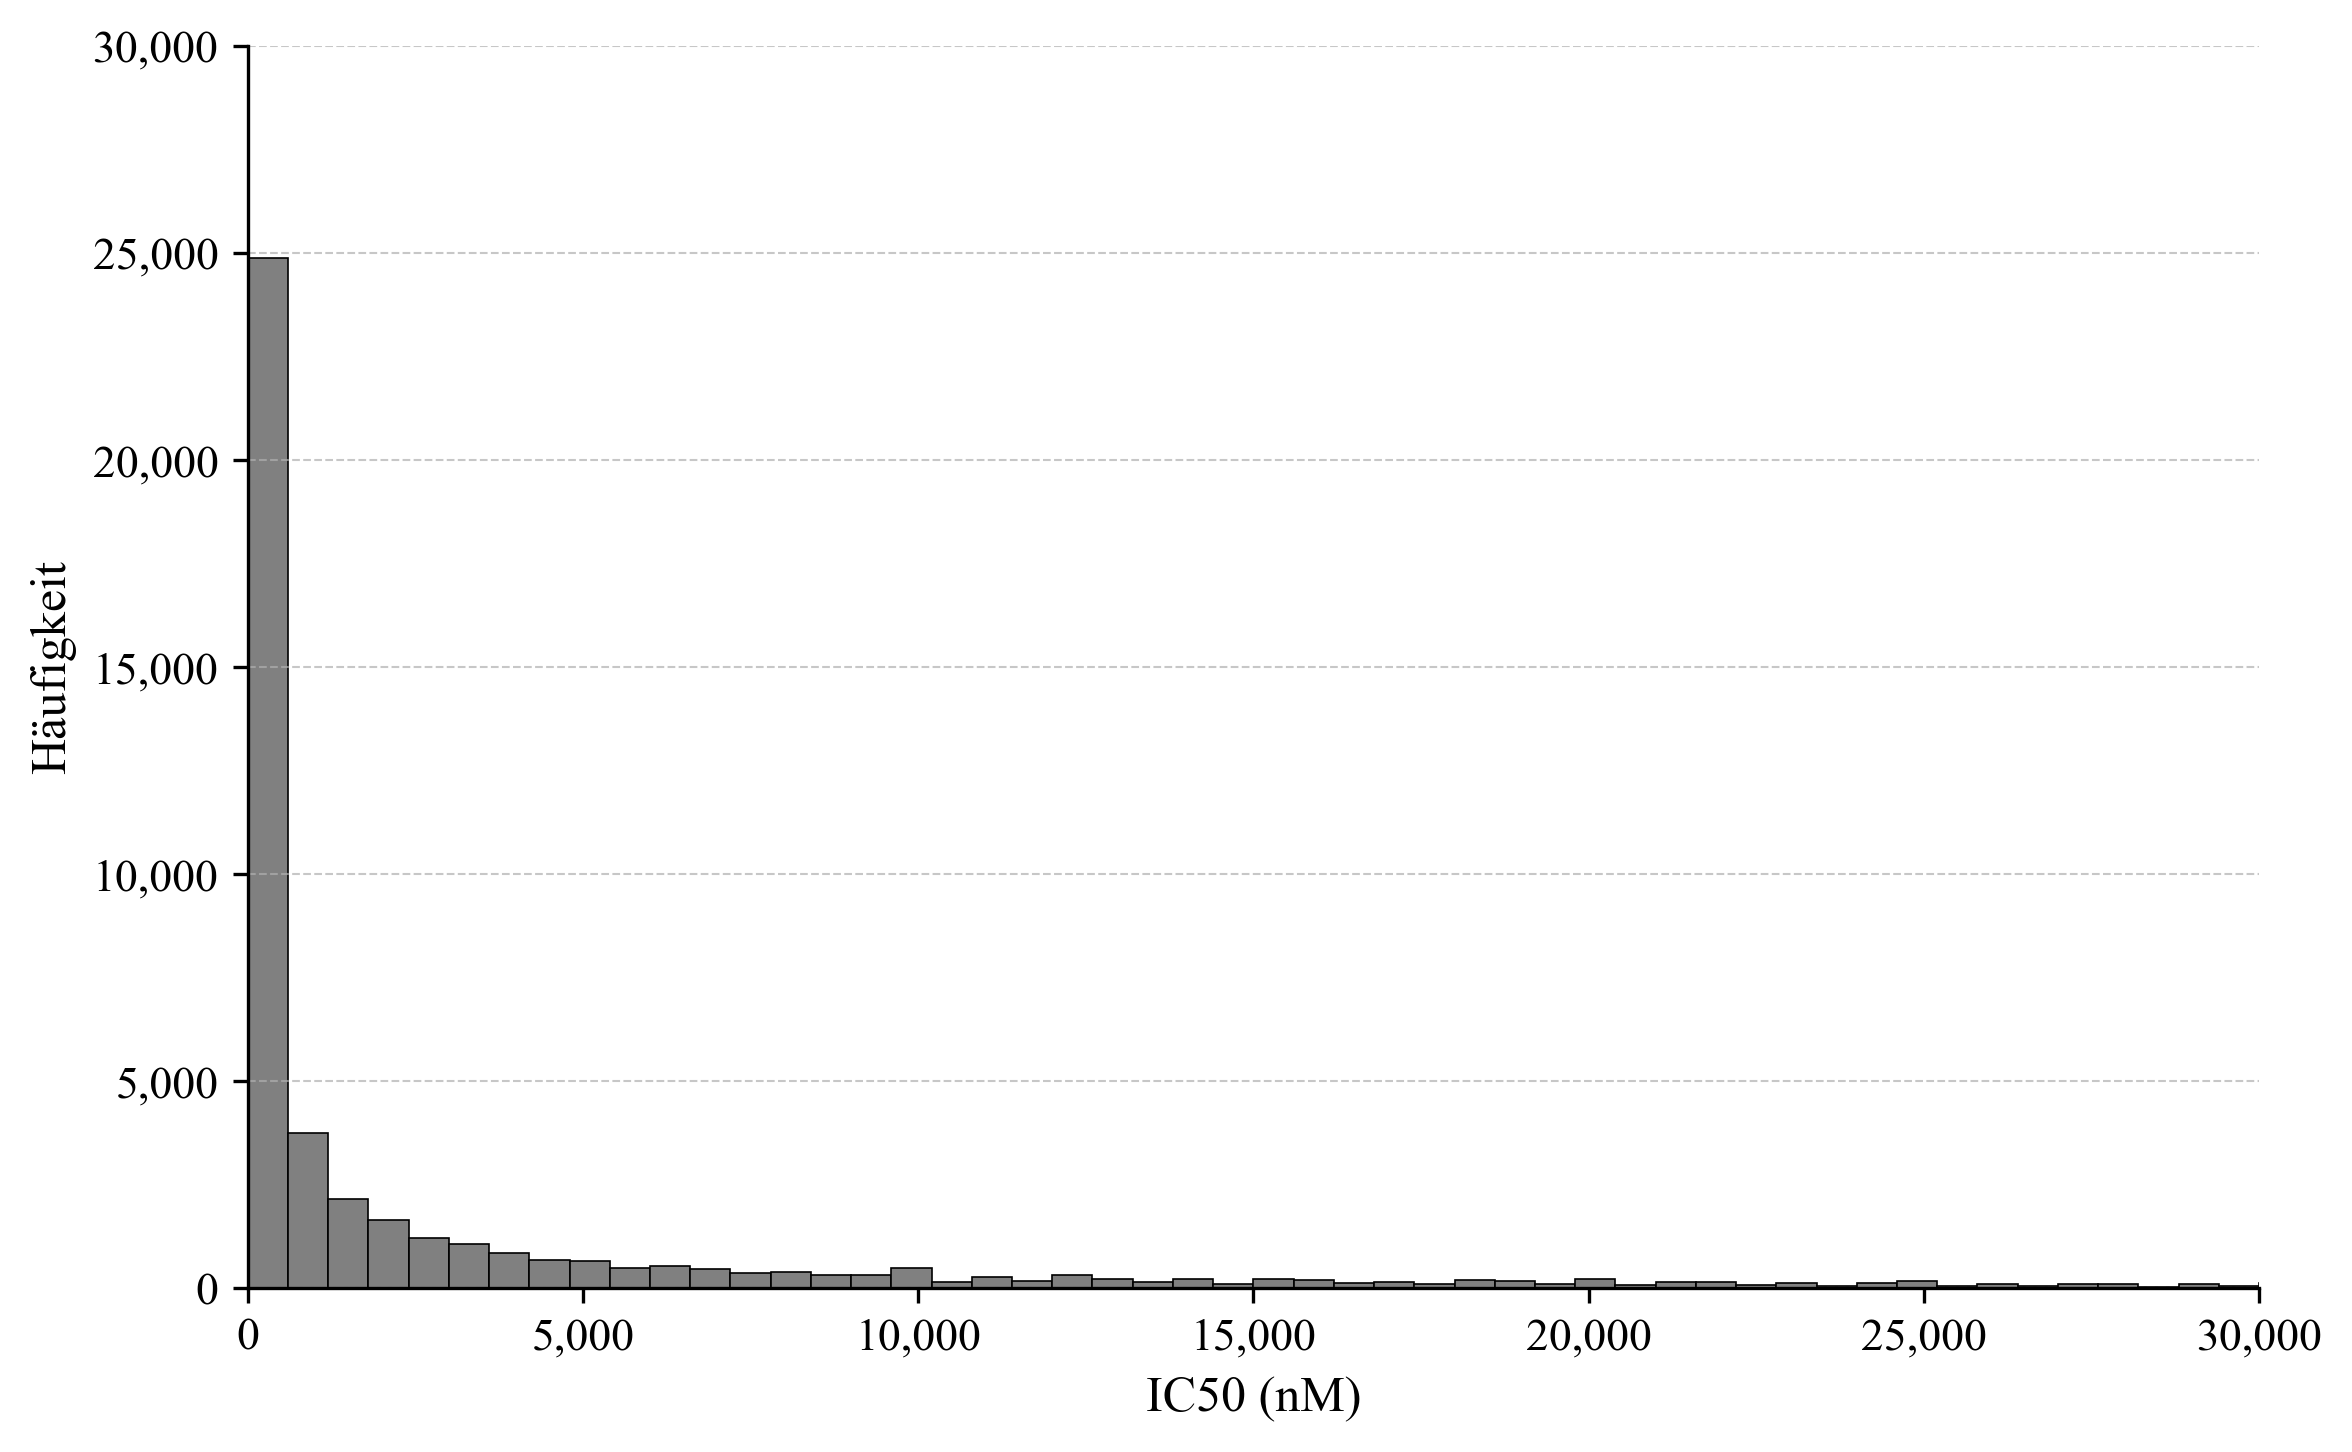

In [431]:
# Schriftart und allgemeines Layout für wissenschaftliche Abbildungen
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# Histogram of IC50 values
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df["ic50_nm"].dropna(),
    bins=100,
    range=(0, 60000),
    color="grey",
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("IC50 (nM)")
ax.set_ylabel("Häufigkeit")
#ax.set_title("Verteilung der IC50-Werte")

# Achsenbegrenzung
ax.set_xlim(0, 30000)
ax.set_ylim(0, 30000)

# Keine wissenschaftliche Schreibweise
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Dezente horizontale Hilfslinien
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

# Obere und rechte Rahmenlinie entfernen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Für Masterarbeit speichern
plt.savefig("reports/histogram_ic50_values.png", dpi=300, bbox_inches="tight")

plt.show()

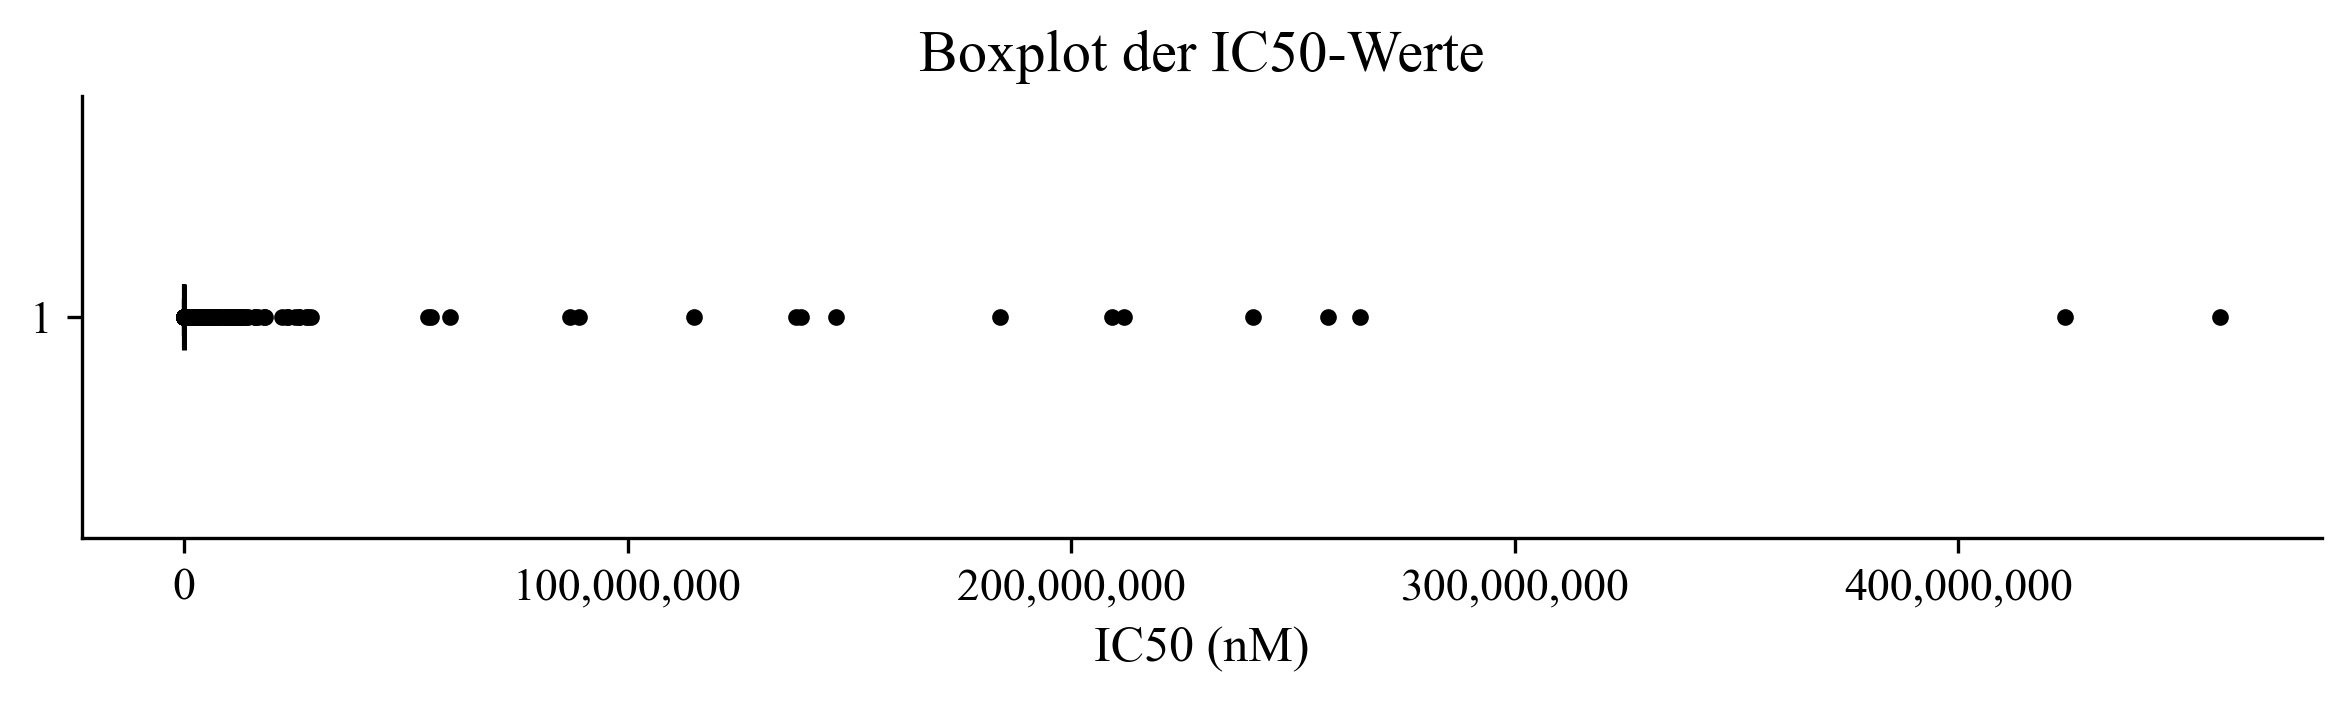

In [432]:
# Schriftart und allgemeines Layout für wissenschaftliche Abbildungen
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# IC50-Werte vorbereiten
ic50 = df["ic50_nm"].dropna()

# Boxplot der IC50-Werte vor logarithmischer Transformation
fig, ax = plt.subplots(figsize=(8, 2.5))

ax.boxplot(
    ic50,
    vert=False,
    showfliers=True,
    patch_artist=True,
    boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.0),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0),
    flierprops=dict(
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=3,
        linestyle="none"
    )
)

ax.set_xlabel("IC50 (nM)")
ax.set_title("Boxplot der IC50-Werte")

# Keine wissenschaftliche Schreibweise auf der x-Achse
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Obere und rechte Rahmenlinie entfernen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Speichern; vorhandene Dateien werden automatisch überschrieben
plt.savefig("reports/boxplot_ic50_values.png", dpi=300, bbox_inches="tight")

plt.show()

In [433]:
# pIC50 berechnen
pic50 = -np.log10(df["ic50_nm"] * 1e-9)
pic50.describe()

count   52,192.00
mean         6.18
std          1.45
min          0.34
25%          5.08
50%          6.13
75%          7.24
max         11.52
Name: ic50_nm, dtype: float64

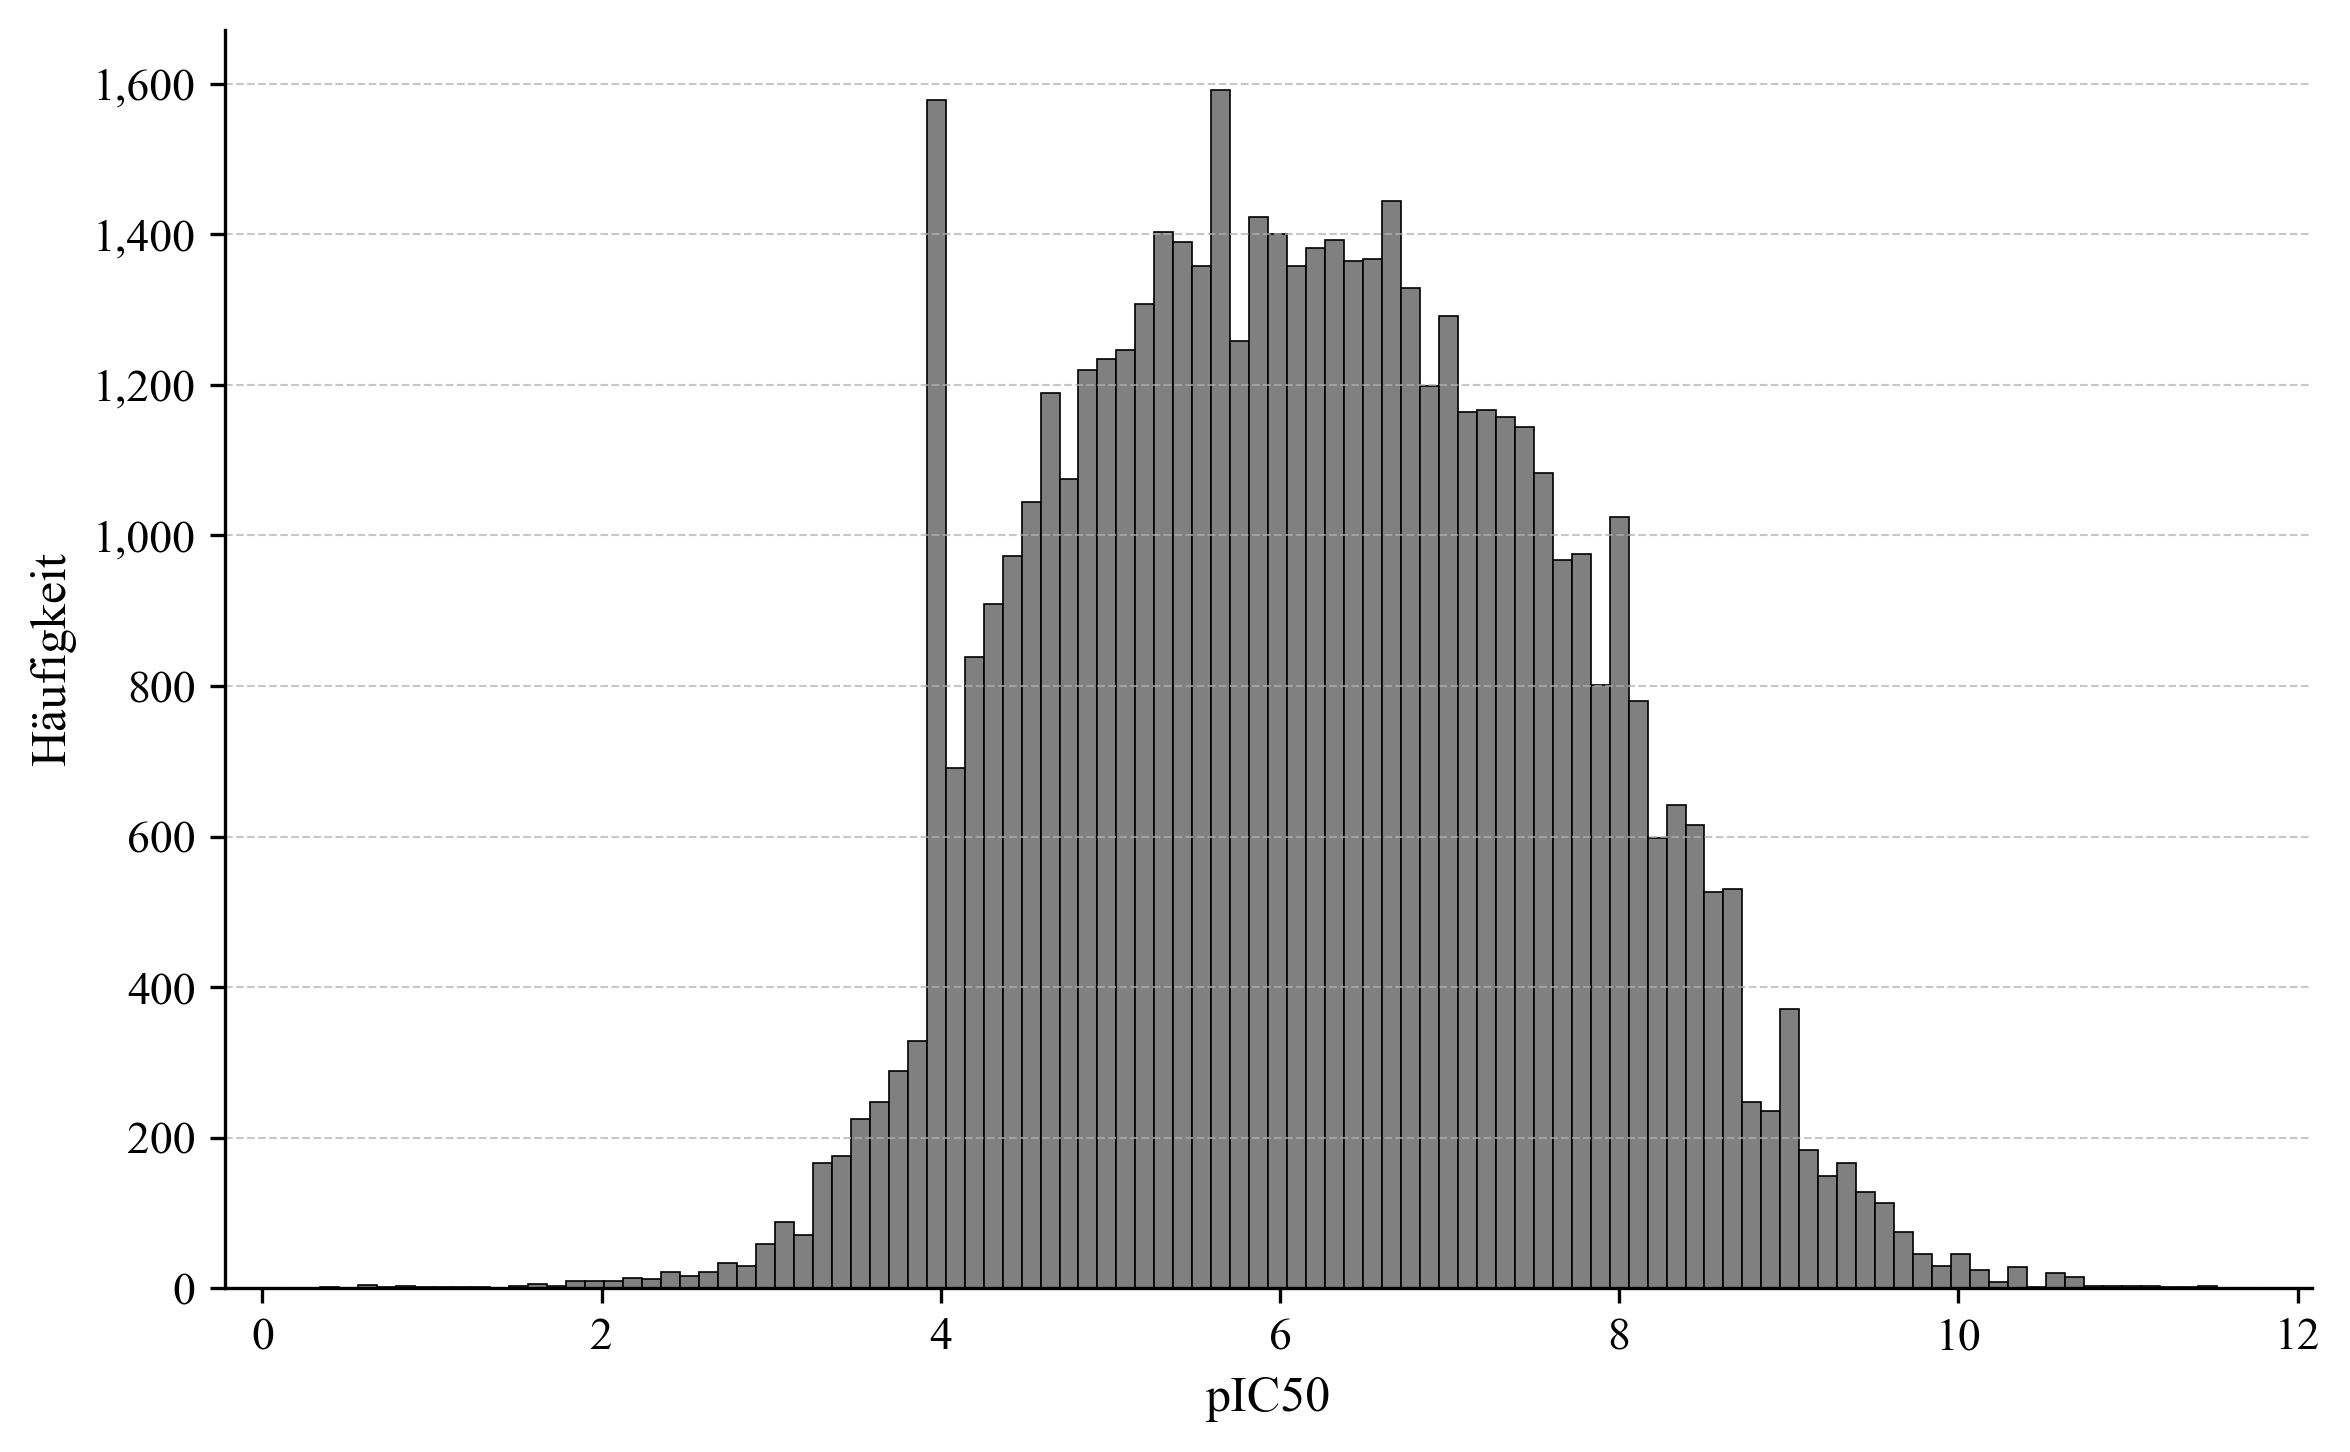

In [434]:
# Schriftart und allgemeines Layout für wissenschaftliche Abbildungen
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# Plot histogram of pIC50 values
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    pic50,
    bins=100,
    color="grey",
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("pIC50")
ax.set_ylabel("Häufigkeit")
#ax.set_title("Verteilung der pIC50-Werte")

# Keine wissenschaftliche Schreibweise auf der y-Achse
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Dezente horizontale Hilfslinien
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

# Obere und rechte Rahmenlinie entfernen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Für Masterarbeit speichern
plt.savefig("reports/histogram_pic50_values.png", dpi=300, bbox_inches="tight")


plt.show()

In [435]:
pic50.describe()

count   52,192.00
mean         6.18
std          1.45
min          0.34
25%          5.08
50%          6.13
75%          7.24
max         11.52
Name: ic50_nm, dtype: float64

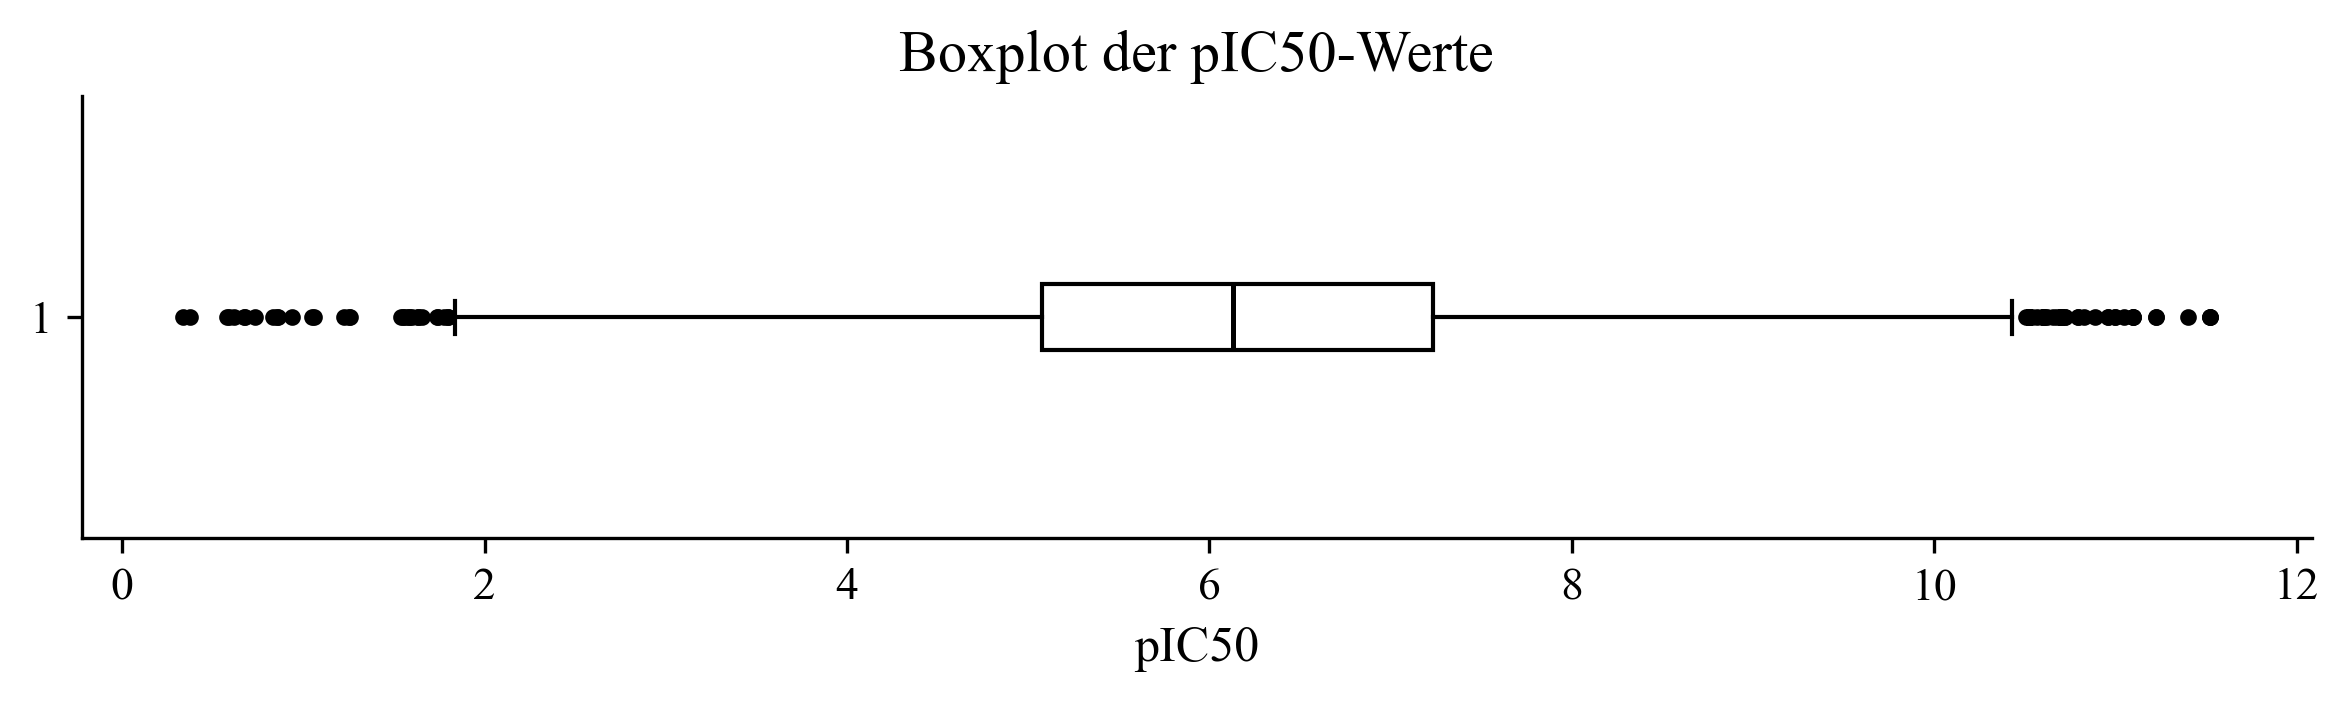

In [436]:

# Schriftart und allgemeines Layout für wissenschaftliche Abbildungen
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# Boxplot der pIC50-Werte
fig, ax = plt.subplots(figsize=(8, 2.5))

ax.boxplot(
    pic50.dropna(),
    vert=False,
    showfliers=True,
    patch_artist=True,
    boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.0),
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(color="black", linewidth=1.0),
    capprops=dict(color="black", linewidth=1.0),
    flierprops=dict(
        marker='o',
        markerfacecolor='black',
        markeredgecolor='black',
        markersize=3,
        linestyle='none'
    )
)

ax.set_xlabel("pIC50")
ax.set_title("Boxplot der pIC50-Werte")

# Obere und rechte Rahmenlinie entfernen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Speichern (vorhandene Dateien werden mit gleichem Namen automatisch überschrieben)
plt.savefig("reports/boxplot_pic50_values.png", dpi=300, bbox_inches="tight")


plt.show()

## Verteilung der SMILES Längen

In [437]:
df["smiles_length"] = df["ligand_smiles"].str.len()

df["smiles_length"].describe()

count   52,192.00
mean        67.32
std         76.87
min          2.00
25%         40.00
50%         51.00
75%         65.00
max      1,535.00
Name: smiles_length, dtype: float64

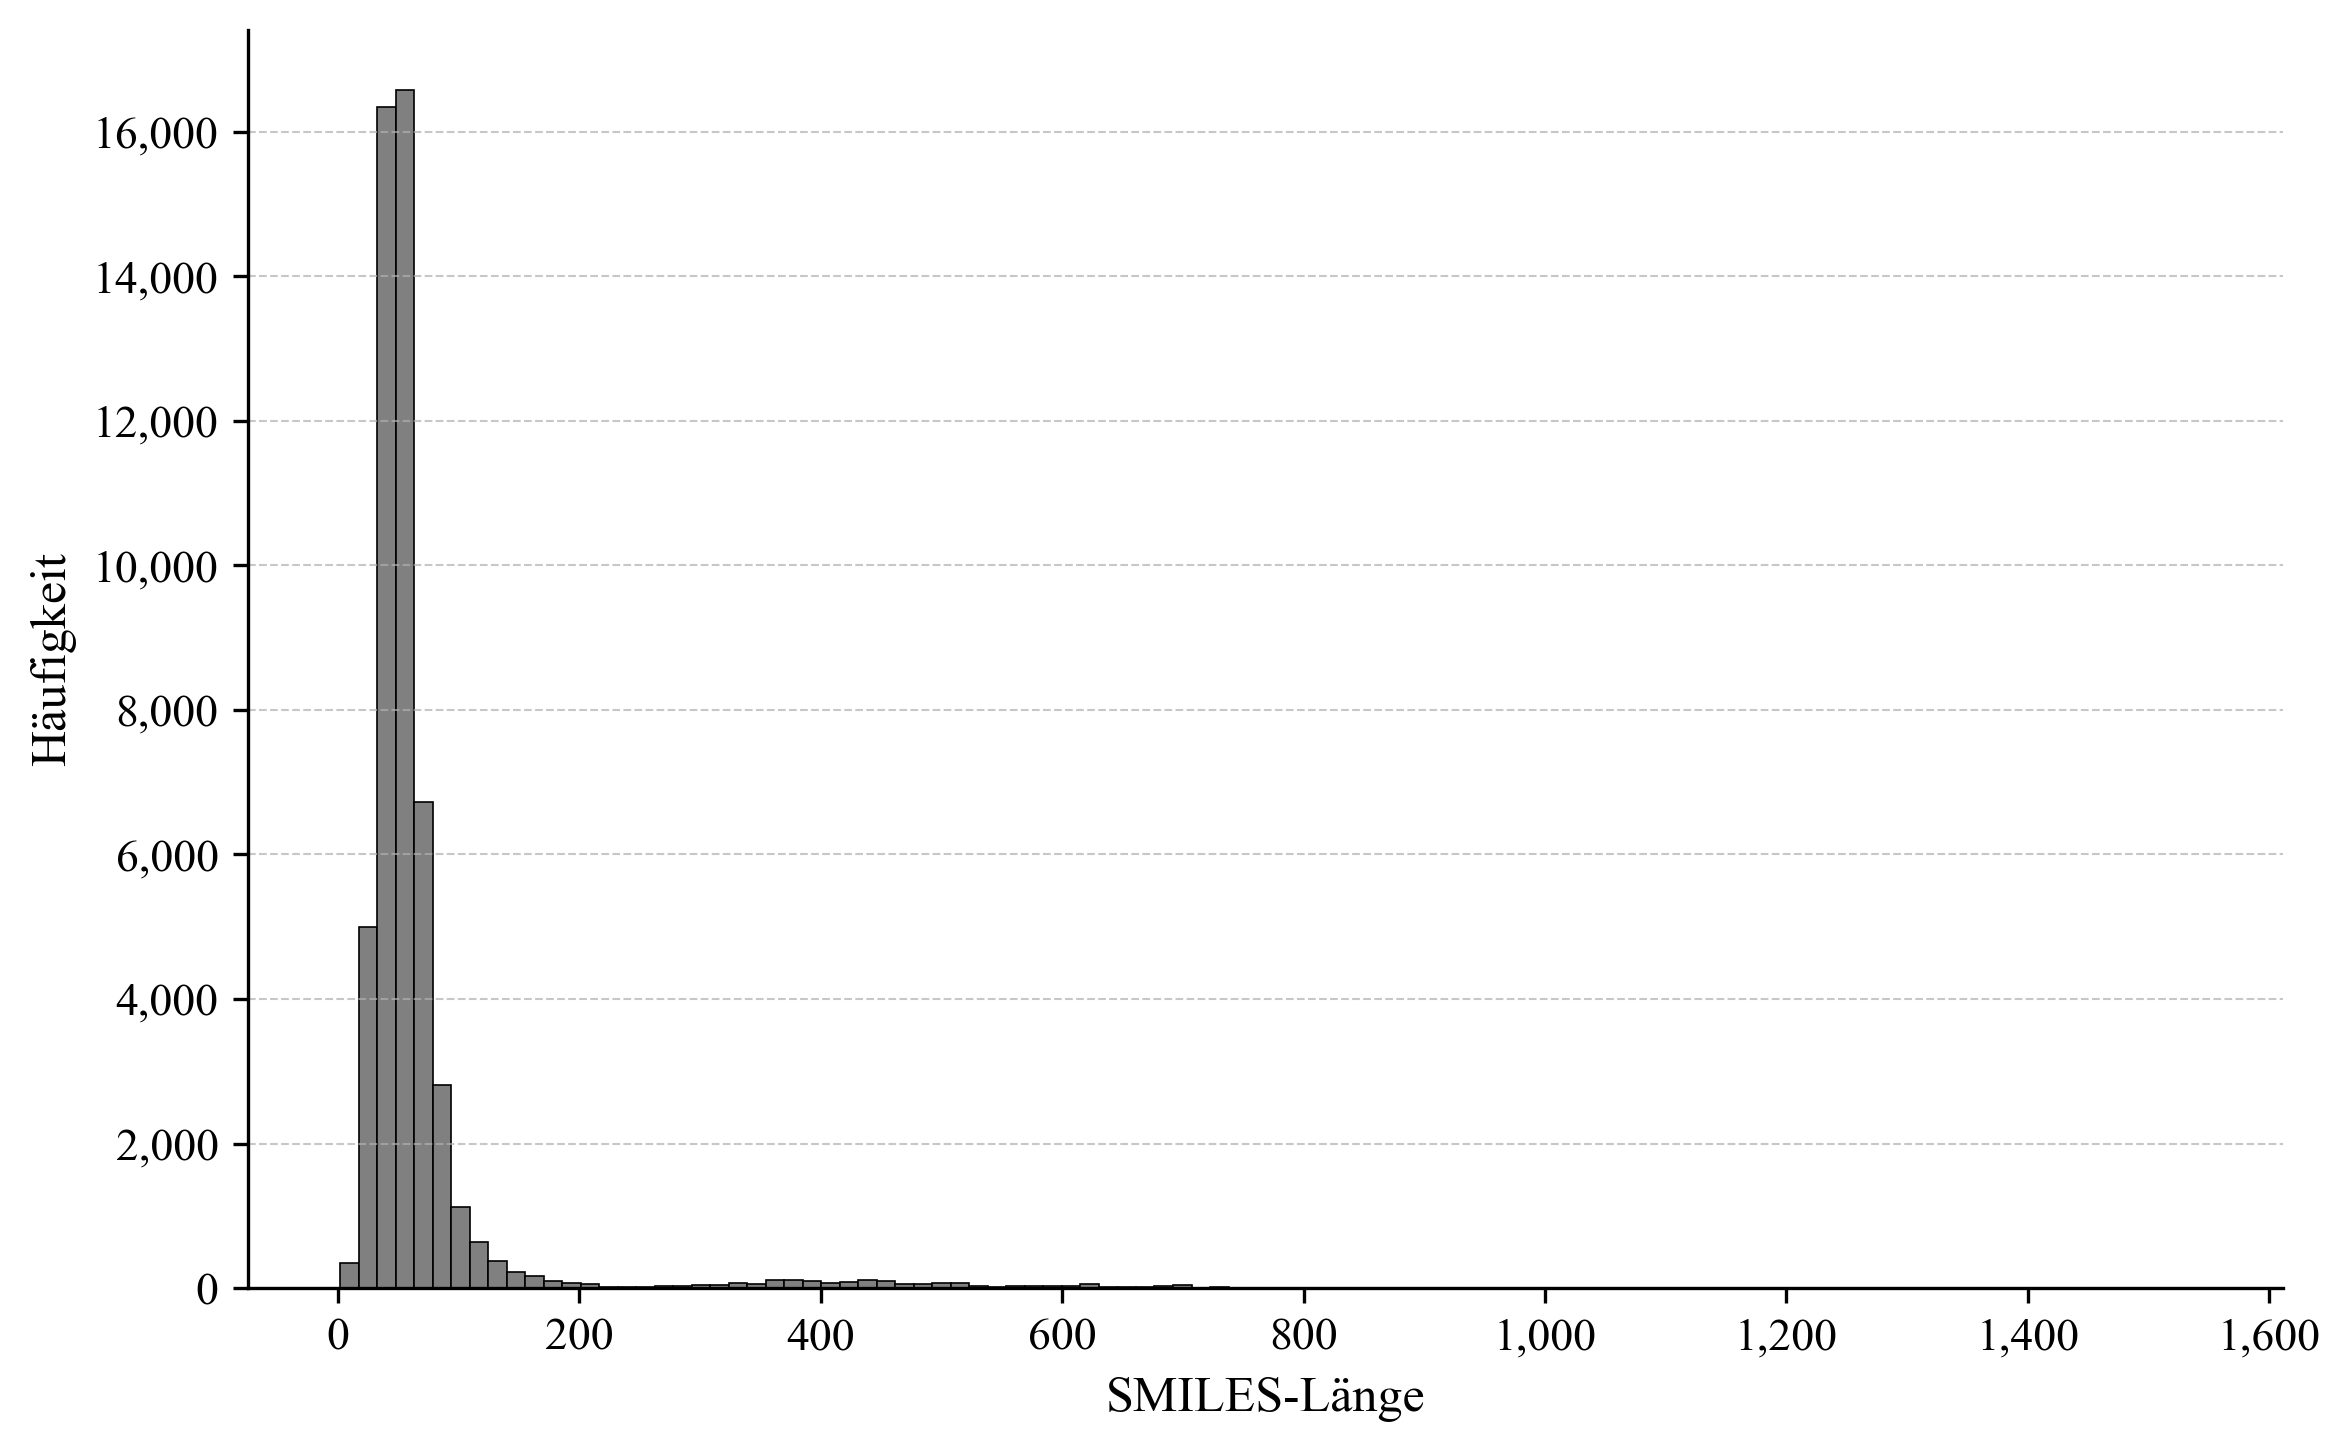

In [445]:
# Schriftart und allgemeines Layout für wissenschaftliche Abbildungen
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# Falls noch nicht vorhanden: SMILES-Länge berechnen
df["smiles_length"] = df["ligand_smiles"].str.len()

# Histogramm der SMILES-Längen
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df["smiles_length"].dropna(),
    bins=100,
    color="grey",
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("SMILES-Länge")
ax.set_ylabel("Häufigkeit")
#ax.set_title("Verteilung der SMILES-Längen")

# Keine wissenschaftliche Schreibweise
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Dezente horizontale Hilfslinien
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

# Obere und rechte Rahmenlinie entfernen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Speichern; vorhandene Dateien werden automatisch überschrieben
plt.savefig("reports/histogram_smiles_lengths.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/histogram_smiles_lengths.pdf", bbox_inches="tight")

plt.show()

## Verteilung der Proteinslängen

In [439]:
df["protein_length"] = df["protein_sequence"].str.len()

df["protein_length"].describe()

count   52,192.00
mean     1,172.67
std      1,883.64
min         18.00
25%        360.00
50%        536.00
75%        822.00
max      7,132.00
Name: protein_length, dtype: float64

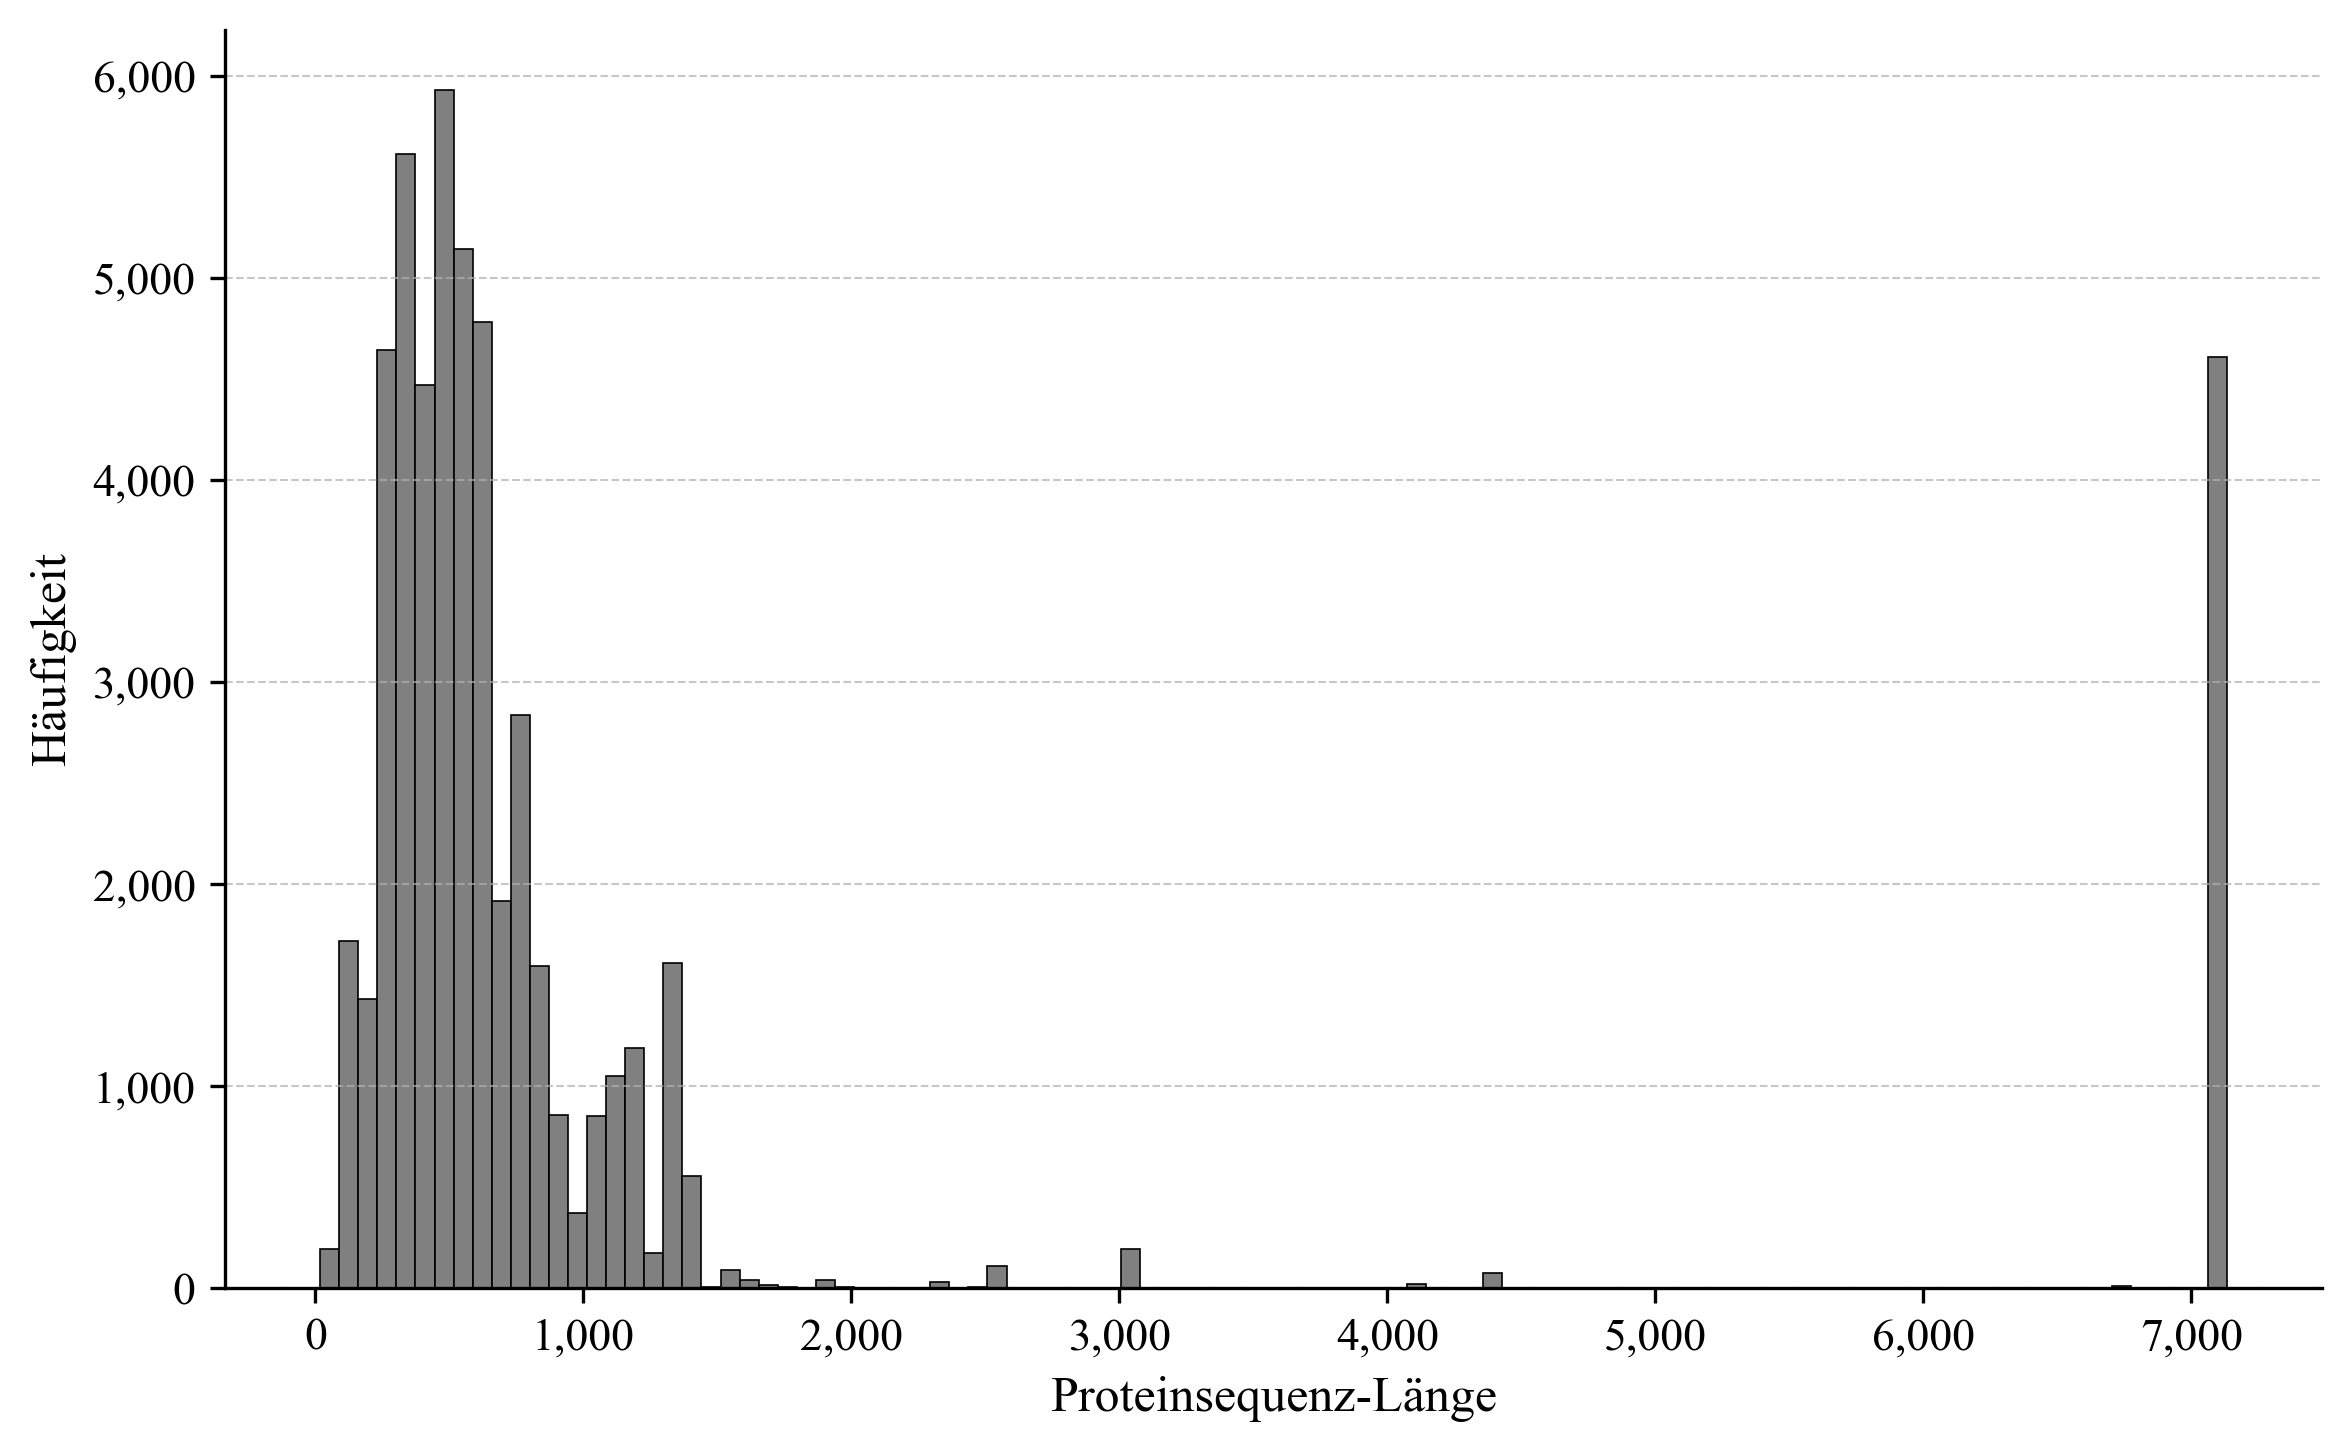

In [446]:
# Schriftart und allgemeines Layout für wissenschaftliche Abbildungen
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# Proteinsequenz-Länge berechnen
df["protein_length"] = df["protein_sequence"].str.len()

# Histogramm der Proteinsequenz-Längen
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df["protein_length"].dropna(),
    bins=100,
    color="grey",
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("Proteinsequenz-Länge")
ax.set_ylabel("Häufigkeit")
#ax.set_title("Verteilung der Proteinsequenz-Längen")

# Keine wissenschaftliche Schreibweise
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Dezente horizontale Hilfslinien
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

# Obere und rechte Rahmenlinie entfernen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Speichern; vorhandene Dateien werden automatisch überschrieben
plt.savefig("reports/histogram_protein_sequence_lengths.png", dpi=300, bbox_inches="tight")

plt.show()

## Verteilung der Protein-Ligand Interaktionen

In [441]:

# zähle spalten mit eindeutigen Werten in der Spalte 'protein_sequence'
unique_counts_protein = df['protein_sequence'].nunique()

# zähle spalten mit eindeutigen Werten in der Spalte 'Ligand SMILES'
unique_counts_ligand = df['ligand_smiles'].nunique()

# zähle spalten mit eindeutigen Werten in der Kombination aus 'Ligand SMILES' und 'protein_sequence'
unique_counts_drug_target = df[["ligand_smiles", "protein_sequence"]].drop_duplicates().shape[0]

df_duplicates = pd.DataFrame({
    "Messgröße": ["Anzahl der Datensätze","Proteins", "Liganden","Drug-Target-Paare"],
    "Anzahl eindeutiger Werte": [len(df), unique_counts_protein, unique_counts_ligand, unique_counts_drug_target]
})

df_duplicates

,Messgröße,Anzahl eindeutiger Werte
0,Anzahl der Datensätze,52192
1,Proteins,1394
2,Liganden,33401
3,Drug-Target-Paare,49364


In [442]:
# Berechne die Anzahl der Interaktionen pro Protein
interactions_per_protein = df.groupby("protein_sequence").size()
# Zeige die Verteilung der Anzahl der Interaktionen pro Protein
interactions_per_protein.describe()

count   1,394.00
mean       37.44
std       139.53
min         1.00
25%         3.00
50%         8.00
75%        25.00
max     3,831.00
dtype: float64

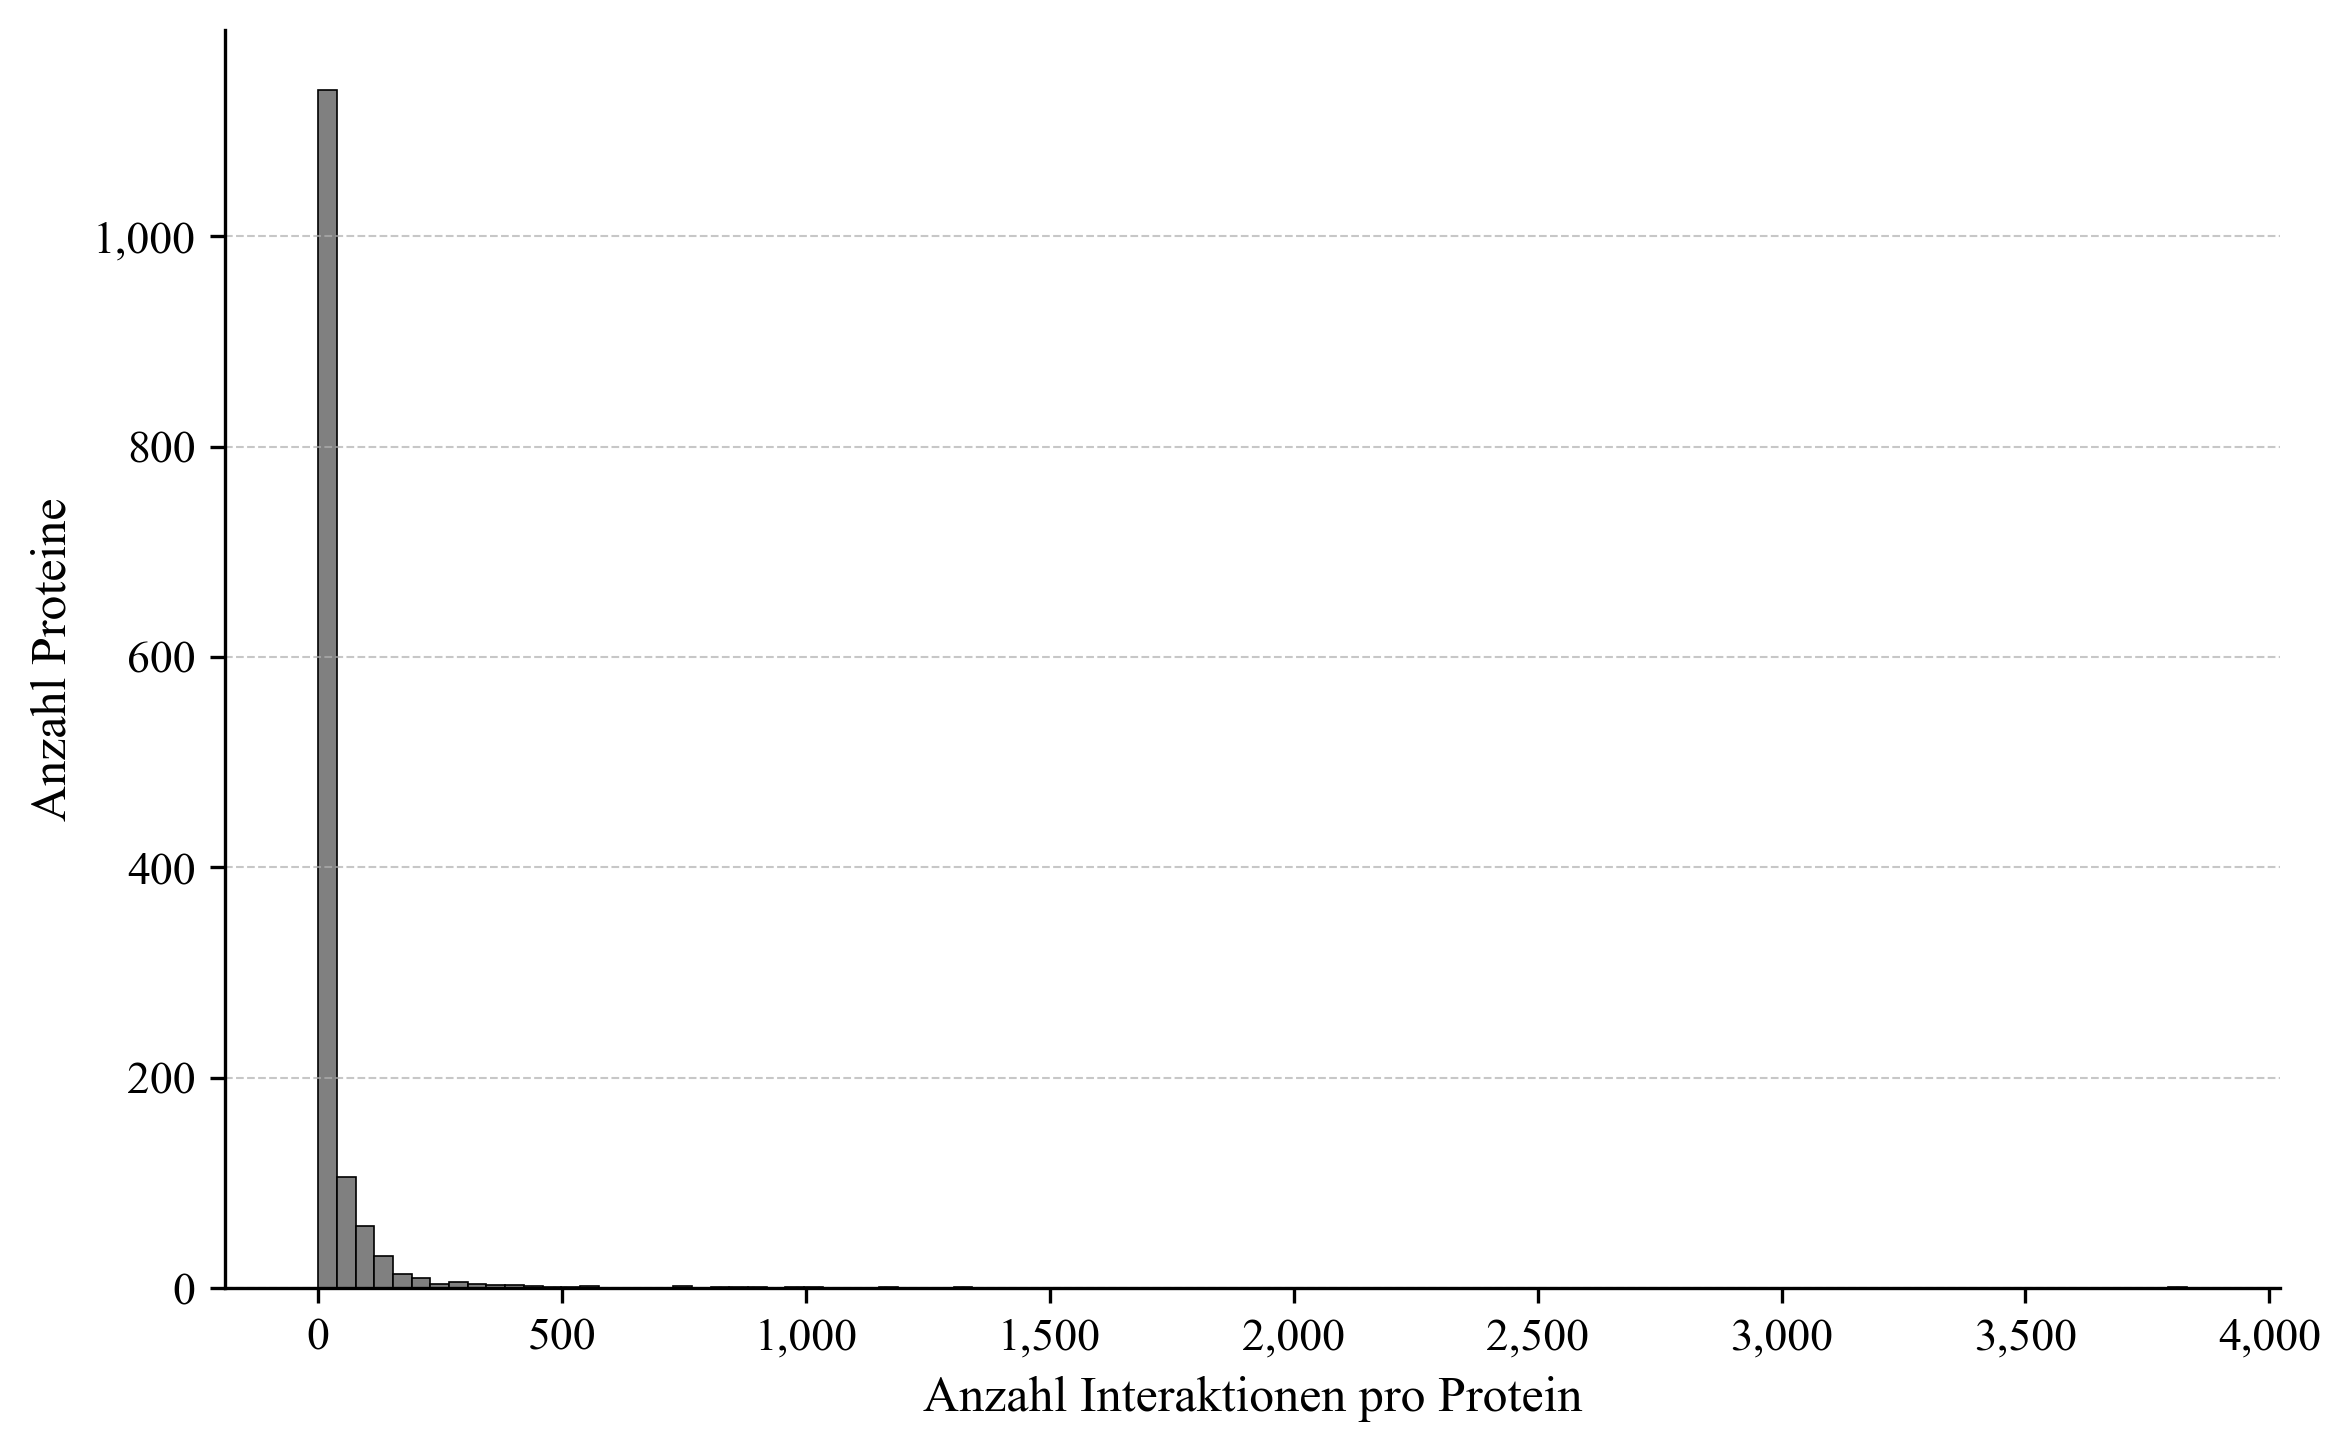

In [449]:
# Anzahl Interaktionen pro Protein berechnen
interactions_per_protein = df.groupby("protein_sequence").size()

# Schriftart und allgemeines Layout für wissenschaftliche Abbildungen
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300
})

# Histogramm: Wie viele Proteine haben wie viele Interaktionen?
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    interactions_per_protein,
    bins=100,
    color="grey",
    edgecolor="black",
    linewidth=0.4
)

ax.set_xlabel("Anzahl Interaktionen pro Protein")
ax.set_ylabel("Anzahl Proteine")

# Keine wissenschaftliche Schreibweise
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

# Dezente horizontale Hilfslinien
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

# Obere und rechte Rahmenlinie entfernen
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("reports/histogram_interactions_per_protein.png", dpi=300, bbox_inches="tight")
plt.savefig("reports/histogram_interactions_per_protein.pdf", bbox_inches="tight")

plt.show()

In [450]:
# Anzahl Interaktionen pro Protein berechnen
interactions_per_protein = df.groupby("protein_sequence").size()

# Tabelle erstellen: Wie viele Proteine haben jeweils x Interaktionen?
protein_interaction_table = (
    interactions_per_protein
    .value_counts()
    .sort_index(ascending=False)
    .reset_index()
)

# Spalten umbenennen
protein_interaction_table.columns = [
    "Anzahl der Interaktionen pro Protein",
    "Anzahl der Proteine"
]

# Rang hinzufügen
protein_interaction_table.insert(
    0,
    "Rang",
    range(1, len(protein_interaction_table) + 1)
)

protein_interaction_table

,Rang,Anzahl der Interaktionen pro Protein,Anzahl der Proteine
0,1,3831,1
1,2,1306,1
2,3,1162,1
3,4,1023,1
4,5,975,1
5,6,912,1
6,7,851,1
7,8,824,1
8,9,751,1
9,10,749,1


In [443]:
# Top 20 Proteine nach Anzahl der Interaktionen
top20_proteins = interactions_per_protein.sort_values(ascending=False).head(20)

top20_proteins_df = top20_proteins.reset_index(drop=True).reset_index()

top20_proteins_df.columns = ["Rang", "Anzahl Interaktionen"]

top20_proteins_df["Rang"] = top20_proteins_df["Rang"] + 1

top20_proteins_df

,Rang,Anzahl Interaktionen
0,1,3831
1,2,1306
2,3,1162
3,4,1023
4,5,975
5,6,912
6,7,851
7,8,824
8,9,751
9,10,749


In [444]:
# Bei gleichen Ligand-Protein-Paaren können unterschiedliche IC50-Werte vorliegen. Wir wollen uns die Paare anschauen, bei denen mehr als ein IC50-Wert vorliegt und die Standardabweichung der IC50-Werte berechnen.
pair_stats = df.groupby(["ligand_smiles", "protein_sequence"])["ic50_nm"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    max="max"
).reset_index()

repeated_pairs = pair_stats[pair_stats["count"] > 1]

repeated_pairs.sort_values("std", ascending=False).head(10)

,ligand_smiles,protein_sequence,count,mean,std,min,max
19566,"COC[C@H]1OC(=O)c2coc3c2[C@@]1(C)C1=C([C@@H]2CCC(=O)[C@@]2(C)C[C@H]1OC(C)=O)C3=O |r,t:16|",MSAEGYQYRALYDYKKEREEDIDLHLGDILTVNKGSLVALGFSDGQEARPEEIGWLNGYNETTGERGDFPGTYVEYIGRKKISPPTPKPRPPRPLPVAPGSSKTEADVEQQALTLPDLAEQFAPPDIAPPLLIKLVEAIEKKGLECSTLYRTQSSSNLAELRQLLDCDTPSVDLEMIDVHVLADAFKRYLLDLPNPVIPAAVYSEMISLAPEVQSSEEYIQLLKKLIRSPSIPHQYWLTLQYLLKHFFKLSQTSSKNLLNARVLSEIFSPMLFRFSAASSDNTENLIKVIEILISTEWNERQPAPALPPKPPKPTTVANNGMNNNMSLQDAEWYWGDISREEVNEKLRDTADGTFLVRDASTKMHGDYTLTLRKGGNNKLIKIFHRDGKYGFSDPLTFSSVVELINHYRNESLAQYNPKLDVKLLYPVSKYQQDQVVKEDNIEAVGKKLHEYNTQFQEKSREYDRLYEEYTRTSQEIQMKRTAIEAFNETIKIFEEQCQTQERYSKEYIEKFKREGNEKEIQRIMHNYDKLKSRISEIIDSRRRLEEDLKKQAAEYREIDKRMNSIKPDLIQLRKTRDQYLMWLTQKGVRQKKLNEWLGNENTEDQYSLVEDDEDLPHHDEKTWNVGSSNRNKAENLLRGKRDGTFLVRESSKQGCYACSVVVDGEVKHCVINKTATGYGFAEPYNLYSSLKELVLHYQHTSLVQHNDSLNVTLAYPVYAQQRR,4,"36,750,051.55","73,499,965.63",4.20,"147,000,000.00"
48090,[O-]S(=O)(=O)c1ccc2[nH]c3c(cc(cc3c2c1)S([O-])(=O)=O)S([O-])(=O)=O,VEILPFLYLGSAYHASKCEFLANLHITALLNVSRRTSEACATHLHYKWIPVEDSHTADISSHFQEAIDFIDCVREKGGKVLVHCEAGISRSPTICMAYLMKTKQFRLKEAFDYIKQRRSMVSPNFGFMGQLLQYESEILPSTPNPQPPSCQGEAAGSSLIGHLQTLSPDMQGAYCTFPASVLAPVPTHSTVSELSRSPVATATSC,2,"15,550,000.00","14,778,531.73","5,100,000.00","26,000,000.00"
40258,O=C(CCc1ccccc1)Cn1ncnn1,MERPQLDSMSQDLSEALKEATKEVHIRAENSEFMRNFQKGQVSREGFKLVMASLYHIYTALEEEIERNKQNPVYAPLYFPEELHRRAALEQDMAFWYGPHWQEAIPYTPATQHYVKRLHEVGGTHPELLVAHAYTRYLGDLSGGQVLKKIAQKAMALPSSGEGLAFFTFPSIDNPTKFKQLYRARMNTLEMTPEVKHRVTEEAKTAFLLNIELFEELQALLTEEHKDQSPSQTEFLRQRPASLVQDTTSAETPRGKSQISTSSSQTPLLRWVLTLSFLLATVAVGIYAM,2,"4,801,300.00","6,786,386.62","2,600.00","9,600,000.00"
26760,C[C@@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=C[C@]4(C)[C@@]3(F)[C@@H](O)C[C@]2(C)[C@@]1(O)C(=O)COP([O-])([O-])=O,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGHAFNVEFDDSQDKAVLKGGPLDGTYRLIQFHFHWGSLDGQGSEHTVDKKKYAAELHLVHWNTKYGDFGKAVQQPDGLAVLGIFLKVGSAKPGLQKVVDVLDSIKTKGKSADFTNFDPRGLLPESLDYWTYPGSLTTPPLLECVTWIVLKEPISVSSEQVLKFRKLNFNGEGEPEELMVDNWRPAQPLKNRQIKASFK,2,"5,290,000.00","1,286,934.34","4,380,000.00","6,200,000.00"
37626,NC(Cc1ccc(OS(=O)(=O)c2cccc3ccccc23)cc1)C(O)=O,MLEQPYLDLAKKVLDEGHFKPDRTHTGTYSIFGHQMRFDLSKGFPLLTTKKVPFGLIKSELLWFLHGDTNIRFLLQHRNHIWDEWAFEKWVKSDEYHGPDMTDFGHRSQKDPEFAAVYHEEMAKFDDRVLHDDAFAAKYGDLGLVYGSQWRAWHTSKGDTIDQLGDVIEQIKTHPYSRRLIVSAWNPEDVPTMALPPCHTLYQFYVNDGKLSLQLYQRSADIFLGVPFNIASYALLTHLVAHECGLEVGEFIHTFGDAHLYVNHLDQIKEQLSRTPRPAPTLQLNPDKHDIFDFDMKDIKLLNYDPYPAIKAPVAV,2,"1,167,500.00","1,035,911.43","435,000.00","1,900,000.00"
29640,Cc1ccc(O)cc1C,MASPDWGYDDKNGPEQWSKLYPIANGNNQSPVDIKTSETKHDTSLKPISVSYNPATAKEIINVGHSFHVNFEDNDNRSVLKGGPFSDSYRLFQFHFHWGSTNEHGSEHTVDGVKYSAELHVAHWNSAKYSSLAEAASKADGLAVIGVLMKVGEANPKLQKVLDALQAIKTKGKRAPFTNFDPSTLLPSSLDFWTYPGSLTHPPLYESVTWIICKESISVSSEQLAQFRSLLSNVEGDNAVPMQHNNRPTQPLKGRTVRASF,2,"539,525.00","693,636.40","49,050.00","1,030,000.00"
20881,COc1cc(cc(c1OC)OC)Cc2cnc(nc2N)N,MVGSLNCIVAVSQNMGIGKNGDLPWPPLRNEFRYFQRMTTTSSVEGKQNLVIMGKKTWFSIPEKNRPLKGRINLVLSRELKEPPQGAHFLSRSLDDALKLTEQPELANKVDMVWIVGGSSVYKEAMNHPGHLKLFVTRIMQDFESDTFFPEIDLEKYKLLPEYPGVLSDVQEEKGIKYKFEVYEKND,4,"690,000.00","661,412.63","120,000.00","1,620,000.00"
2408,CC(C(O)=O)c1cccc(c1)C(=O)c1ccccc1,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGHAFNVEFDDSQDKAVLKGGPLDGTYRLIQFHFHWGSLDGQGSEHTVDKKKYAAELHLVHWNTKYGDFGKAVQQPDGLAVLGIFLKVGSAKPGLQKVVDVLDSIKTKGKSADFTNFDPRGLLPESLDYWTYPGSLTTPPLLECVTWIVLKEPISVSSEQVLKFRKLNFNGEGEPEELMVDNWRPAQPLKNRQIKASFK,2,"1,400,000.00","636,396.10","950,000.00","1,850,000.00"
29641,Cc1ccc(O)cc1C,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGHAFNVEFDDSQDKAVLKGGPLDGTYRLIQFHFHWGSLDGQGSEHTVDKKKYAAELHLVHWNTKYGDFGKAVQQPDGLAVLGIFLKVGSAKPGLQKVVDVLDSIKTKGKSADFTNFDPRGLLPESLDYWTYPGSLTTPPLLECVTWIVLKEPISVSSEQVLKFRKLNFNGEGEPEELMVDNWRPAQPLKNRQIKASFK,2,"485,650.00","628,405.80","41,300.00","930,000.00"
15377,CN(C)Cc1cc(C)c(C)cc1O,MSHHWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSVSYDQATSLRILNNGHAFNVEFDDSQDKAVLKGGPLDGTYRLIQFHFHWGSLDGQGSEHTVDKKKYAAELHLVHWNTKYGDFGKAVQQPDGLAVLGIF